In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

def clean_prep_standardise(
    data = fetch_california_housing(as_frame=True).frame,
    target_col="MedHouseVal",
    test_size=0.3,
    random_state=42,
    skew_cols=None):
    
    df = data.copy() 

    # Basic cleaning
    df = df.drop_duplicates()
    df = df.dropna()

    # Split into features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Train test split first (prevents leakage)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Adjust for right skewness (log1p) on commonly skewed housing features
    if skew_cols is None:
        skew_cols = ["Population", "AveRooms", "AveBedrms", "AveOccup", "MedInc"]

    X_train = X_train.copy()
    X_test = X_test.copy()

    for c in skew_cols:
        if c in X_train.columns:
            X_train[c] = np.log1p(X_train[c])
            X_test[c] = np.log1p(X_test[c])

    # Standardise features using training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Train shape:", X_train_scaled.shape)
    print("Test shape:", X_test_scaled.shape)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Example call (your teammates can delete this and just call the function)
# X_train_scaled, X_test_scaled, y_train, y_test, scaler = clean_prep_standardise()

In [6]:
cols = ["Population", "AveRooms", "AveBedrms", "AveOccup", "MedInc", "Target"]
cols = [c for c in cols if c in df.columns]

for c in cols:
    plt.figure()
    x = df[c].dropna()
    plt.hist(x, bins=60)
    plt.title(f"Histogram of {c} original")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

NameError: name 'df' is not defined

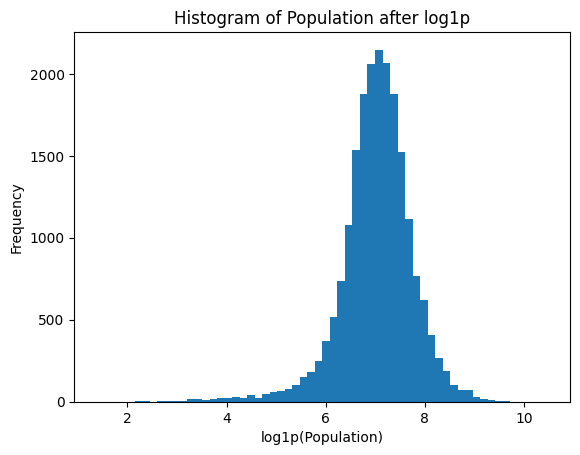

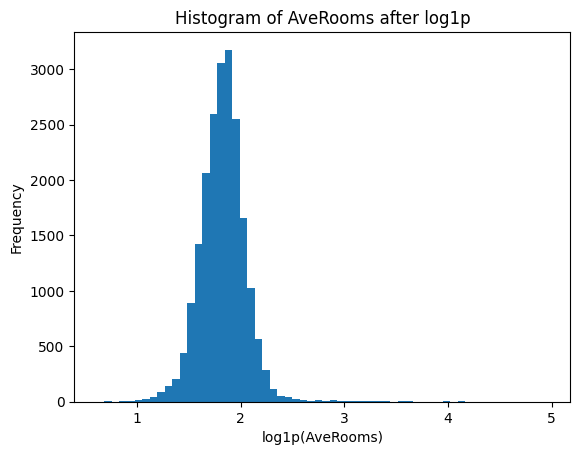

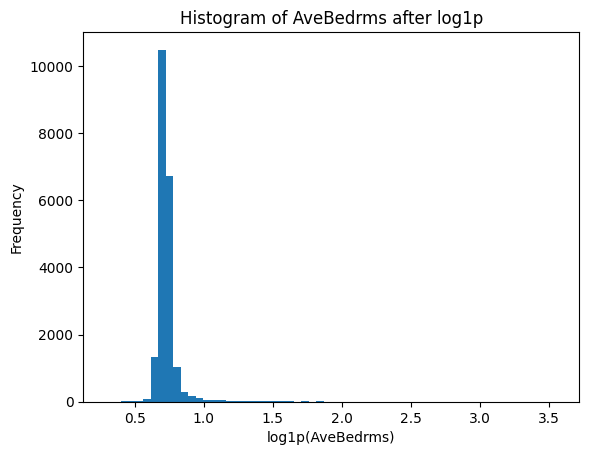

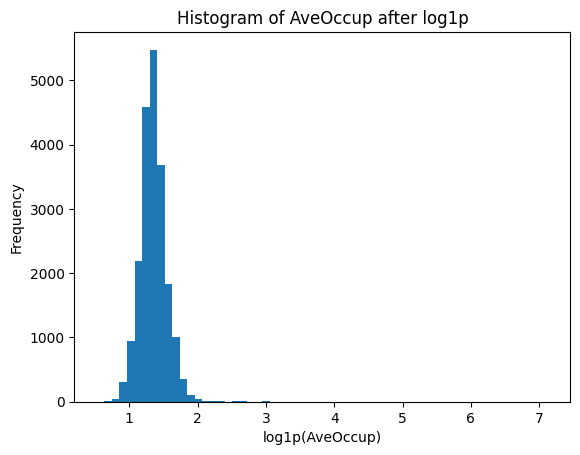

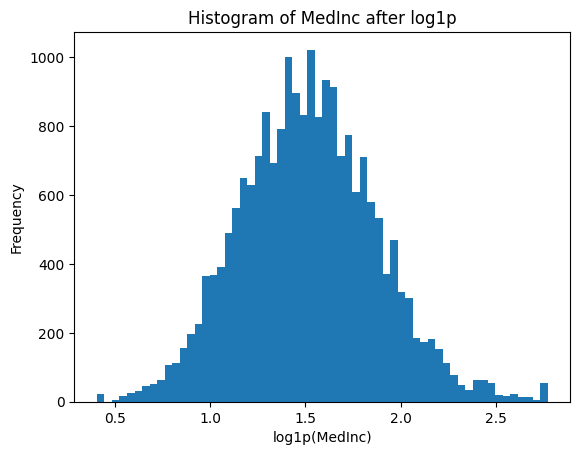

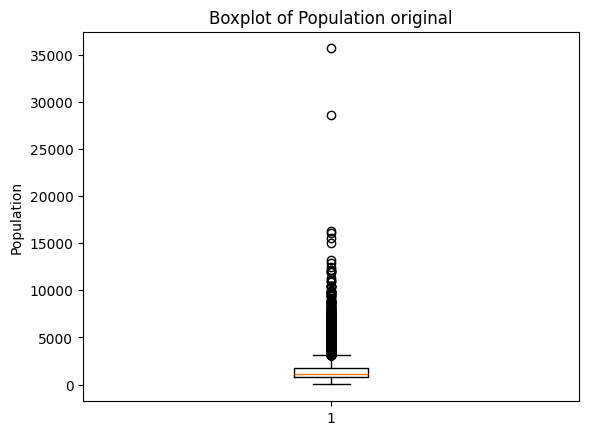

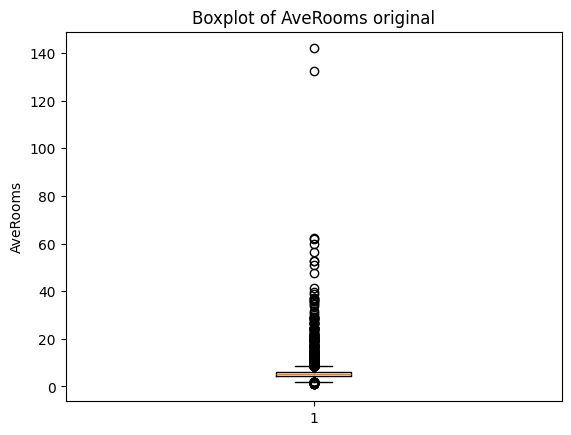

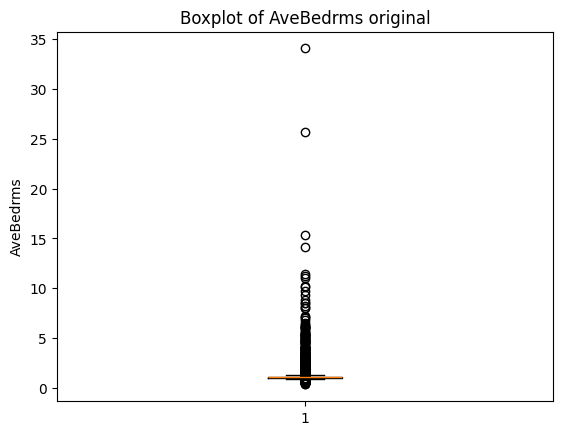

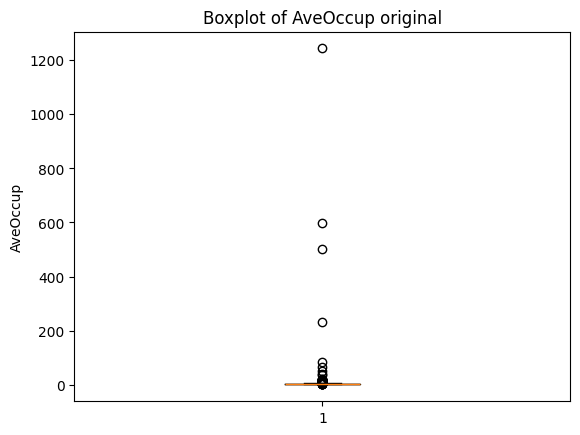

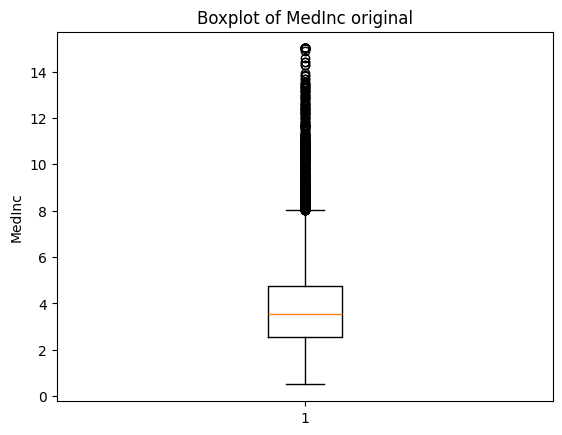

In [ ]:
skew_cols = ["Population", "AveRooms", "AveBedrms", "AveOccup", "MedInc"]
skew_cols = [c for c in skew_cols if c in df.columns]

for c in skew_cols:
    plt.figure()
    x = np.log1p(df[c].dropna())
    plt.hist(x, bins=60)
    plt.title(f"Histogram of {c} after log1p")
    plt.xlabel(f"log1p({c})")
    plt.ylabel("Frequency")
    plt.show()

df = pd.read_excel("california_housing_data.xlsx")
df = df.drop(columns=["Unnamed: 0"], errors="ignore").drop_duplicates()

skew_cols = ["Population", "AveRooms", "AveBedrms", "AveOccup", "MedInc"]
skew_cols = [c for c in skew_cols if c in df.columns]

for c in skew_cols:
    plt.figure()
    x = df[c].dropna()
    plt.boxplot(x, vert=True, showfliers=True)
    plt.title(f"Boxplot of {c} original")
    plt.ylabel(c)
    plt.show()